In [5]:
!pip install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url="C:/Users/Samrath Narula/OneDrive/Desktop/datasets/heart.csv"
df=pd.read_csv(url)
print(df)


     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  target  
0        0   0     1       1  
1        0   0     2     


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1


In [23]:
ss=df.shape
print('the total number of rows and coloumns are:',ss)
print()

# the coloumn with datatype = object
col=df.select_dtypes(include='float64').columns
print(col)
print()
# the coloumn with datatype = integer
col2=df.select_dtypes(include='int64').columns
print(col2)
print()
# to know the datatype of all columns together
print('the datatypes of all columns together are:-')
df.dtypes

the total number of rows and coloumns are: (303, 14)

Index(['oldpeak'], dtype='object')

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

the datatypes of all columns together are:-


age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

# DATA CLEANING 

In [43]:
#Whether the dataset contains missing values
df.isna()     
df.isna().sum() # to Check whether the dataset has missing values

df[df.isnull().any(axis=1)] #Column-wise location

df.isnull().any() #Row-wise 




age         False
sex         False
cp          False
trestbps    False
chol        False
fbs         False
restecg     False
thalach     False
exang       False
oldpeak     False
slope       False
ca          False
thal        False
target      False
dtype: bool

In [7]:
#Check for duplicate rows in the dataset
df = pd.read_csv("C:/Users/Samrath Narula/OneDrive/Desktop/datasets/heart.csv")
dx=df.duplicated().sum()
print('the number of duplicates present in the dataset are :',dx)


the number of duplicates present in the dataset are : 1


In [8]:
print("The duplicate row in the dataset is:\n")
print(df[df.duplicated()])


The duplicate row in the dataset is:

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
164   38    1   2       138   175    0        1      173      0      0.0   

     slope  ca  thal  target  
164      2   4     2       1  


In [9]:
# drop the row with the dupliate dataset
df = df.drop_duplicates()

In [10]:
# Rechekcing the duplicate row present or not 
df.duplicated().sum()
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### DATA visualisation

<Figure size 3000x10000 with 0 Axes>

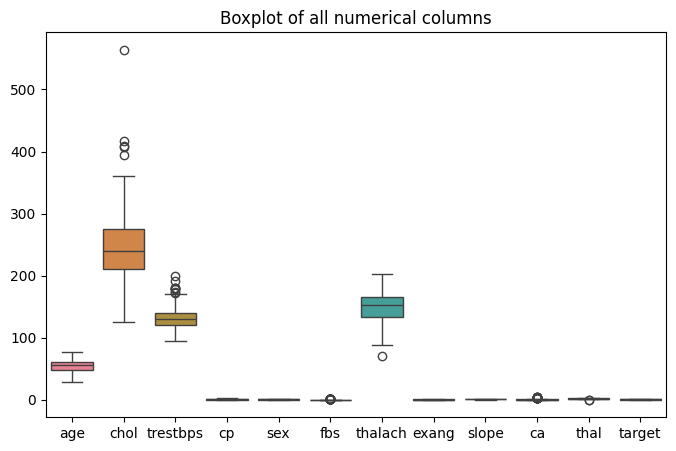

In [79]:
#Boxplot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(30,100))
num_cols = ['age', 'chol', 'trestbps','cp','sex','fbs','thalach', 'exang','slope','ca','thal','target']  # numerical columns
plt.figure(figsize=(8,5))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot of all numerical columns")
plt.show()


In [91]:
# Standardize numeric columns using pandas
dz=df[num_cols] = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()

# Check first 5 rows
print(dz.head(5))



        age      chol  trestbps        cp       sex       fbs   thalach  \
0  0.950624 -0.255910  0.762694  1.969864  0.679881  2.390484  0.015417   
1 -1.912150  0.072080 -0.092585  1.000921  0.679881 -0.416945  1.630774   
2 -1.471723 -0.815424 -0.092585  0.031978 -1.465992 -0.416945  0.975900   
3  0.179877 -0.198030 -0.662770  0.031978  0.679881 -0.416945  1.237849   
4  0.289984  2.078611 -0.662770 -0.936965 -1.465992 -0.416945  0.582975   

     exang     slope        ca      thal    target  
0 -0.69548 -2.270822 -0.713249 -2.145324  0.913019  
1 -0.69548 -2.270822 -0.713249 -0.512075  0.913019  
2 -0.69548  0.974740 -0.713249 -0.512075  0.913019  
3 -0.69548  0.974740 -0.713249 -0.512075  0.913019  
4  1.43311  0.974740 -0.713249 -0.512075  0.913019  


#EXPLORATORY DATA ANALYSIS (EDA)

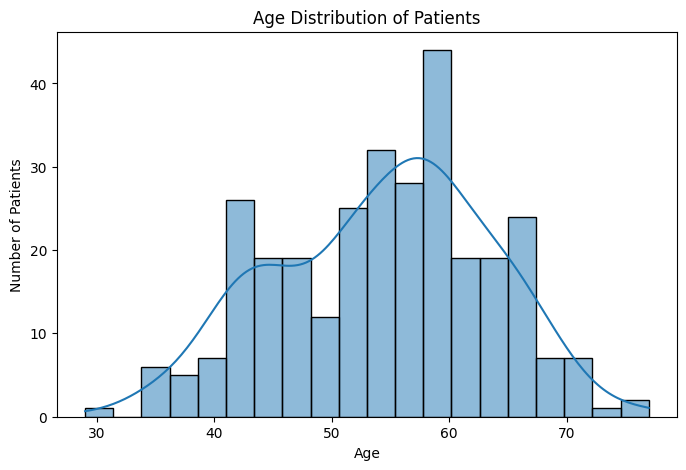

In [12]:
df = pd.read_csv("C:/Users/Samrath Narula/OneDrive/Desktop/datasets/heart.csv")
df.head(5)
import matplotlib.pyplot as plt
import seaborn as sns

# Age distribution through histogram
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


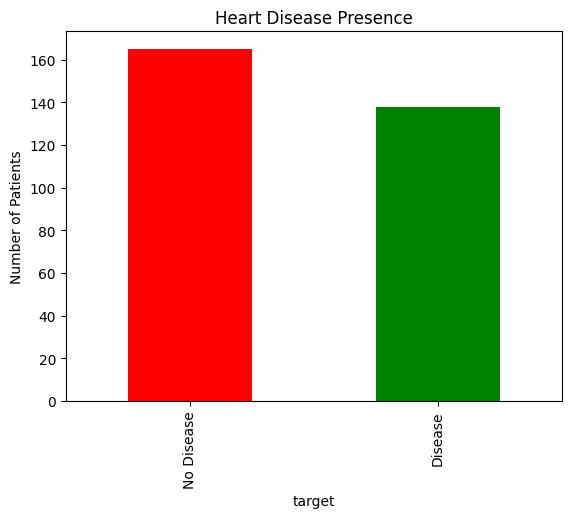

<Figure size 500x500 with 0 Axes>

<Figure size 500x500 with 0 Axes>

In [99]:
#Patients with and without heart disease
df['target'].value_counts().plot(kind='bar', color=['red', 'green'])

plt.xticks(ticks=[0,1], labels=['No Disease', 'Disease'])
plt.ylabel("Number of Patients")
plt.title("Heart Disease Presence")
plt.show()
plt.figure(figsize=(5,5))


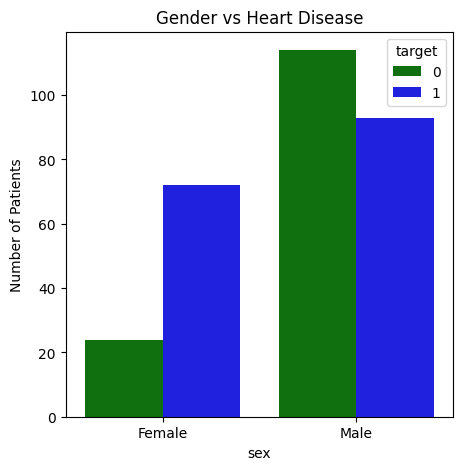

In [103]:
#Gender vs Heart Disease Barchart
plt.figure(figsize=(5,5))
sns.countplot(x='sex', hue='target', data=df, palette=['green', 'blue'])
plt.xticks(ticks=[0,1], labels=['Female', 'Male'])
plt.ylabel("Number of Patients")
plt.title("Gender vs Heart Disease")

plt.show()


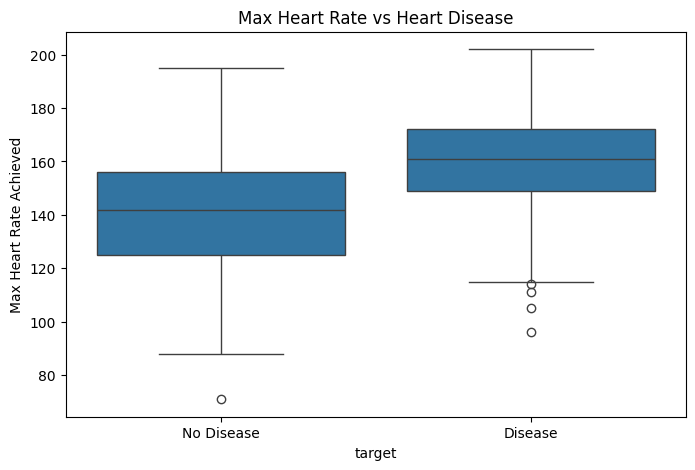

In [104]:
#Maximum heart rate (thalach) vs Heart Disease
plt.figure(figsize=(8,5))
sns.boxplot(x='target', y='thalach', data=df)
plt.xticks([0,1], ['No Disease', 'Disease'])
plt.ylabel("Max Heart Rate Achieved")
plt.title("Max Heart Rate vs Heart Disease")
plt.show()


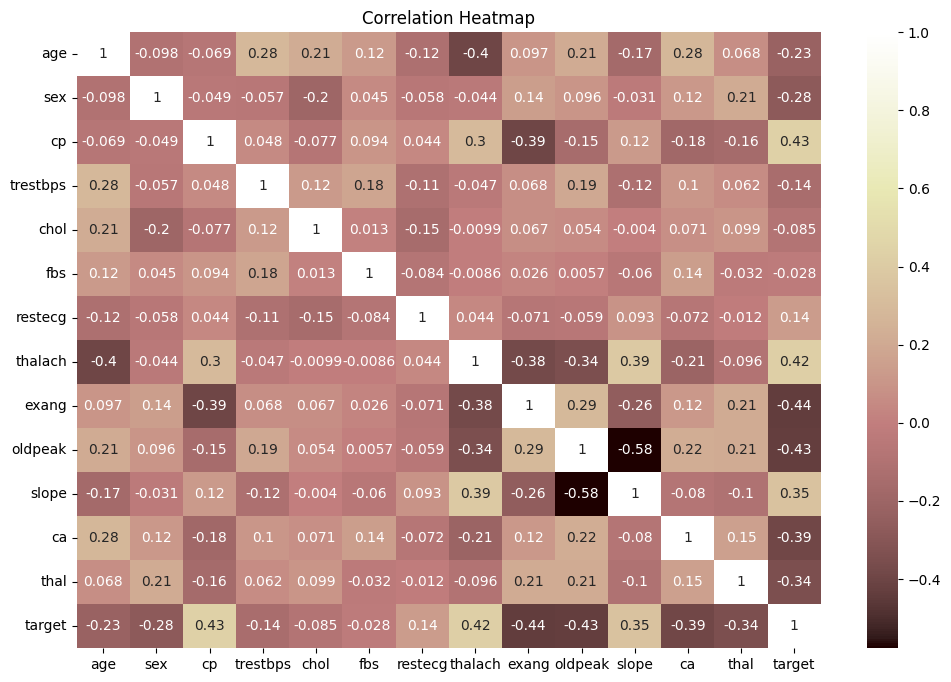

In [107]:
#Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='pink', annot=True)  # fmt optional
plt.title("Correlation Heatmap")
plt.show()


In [108]:
import pandas as pd
# Create age_group column
df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 39, 60, 100], 
                         labels=['Young', 'Middle-aged', 'Senior'])

# View first 5 rows
print(df[['age', 'age_group', 'target']].head())


   age    age_group  target
0   63       Senior       1
1   37        Young       1
2   41  Middle-aged       1
3   56  Middle-aged       1
4   57  Middle-aged       1


Age groups created
   age   age_group
0   63      Senior
1   37       Young
2   41  Middle Age
3   56      Senior
4   57      Senior
Patients with and without heart disease per age group:
age_group   target
Young       1         13
            0          6
Middle Age  1         90
            0         43
Senior      0         88
            1         57
Old         1          5
            0          1
Name: count, dtype: int64


C:\Users\Samrath Narula\AppData\Local\Temp\ipykernel_18752\1451180821.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_disease = df.groupby('age_group')['target'].value_counts()


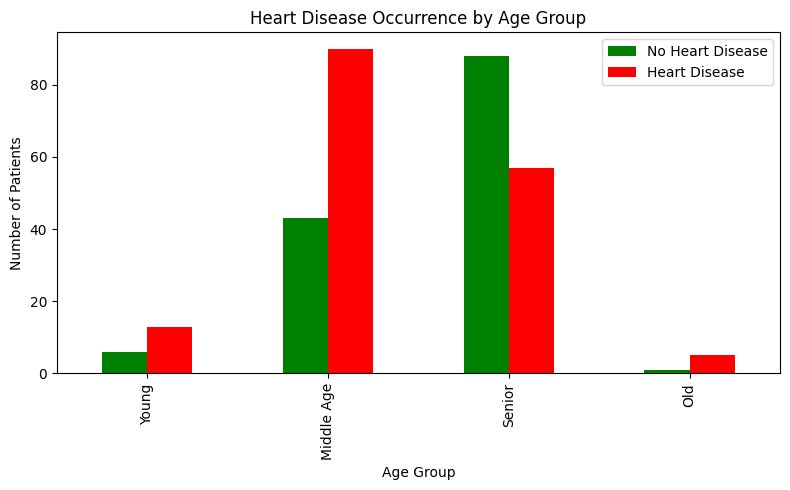

In [20]:

df = pd.read_csv("C:/Users/Samrath Narula/OneDrive/Desktop/datasets/heart.csv")  

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 55, 70, 100],
    labels=['Young', 'Middle Age', 'Senior', 'Old'])
print("Age groups created")
print(df[['age', 'age_group']].head())

age_disease = df.groupby('age_group')['target'].value_counts()
print("Patients with and without heart disease per age group:")
print(age_disease)
age_disease.unstack().plot(
    kind='bar',
    figsize=(8, 5),
    color=['green', 'red'])

plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Occurrence by Age Group")
plt.legend(["No Heart Disease", "Heart Disease"])
plt.tight_layout()
plt.show()


### GUI 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tkinter import *
from tkinter import filedialog, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

df = None
def load_csv():
    global df
    file_path = filedialog.askopenfilename(filetypes=[("CSV Files", "*.csv")])

    if file_path == "":
        return

    try:
        df = pd.read_csv(file_path)
        df.columns = [c.lower() for c in df.columns]

        output.delete(1.0, END)
        output.insert(END, "File Loaded Successfully\n")
        output.insert(END, f"Rows: {df.shape[0]}\n")
        output.insert(END, f"Columns: {df.shape[1]}\n")

    except:
        messagebox.showerror("Error", "Unable to load file")

def calculate_risk():
    global df

    if df is None:
        messagebox.showwarning("Warning", "Please load CSV first")
        return

    df["risk"] = 0

    if "age" in df.columns:
        df.loc[df["age"] > 50, "risk"] += 1

    if "chol" in df.columns:
        df.loc[df["chol"] > 240, "risk"] += 1

    if "trestbps" in df.columns:
        df.loc[df["trestbps"] > 140, "risk"] += 1

    high_risk = (df["risk"] >= 2).sum()

    output.delete(1.0, END)
    output.insert(END, "Risk Calculation Done\n")
    output.insert(END, f"High Risk Patients: {high_risk}\n")

def show_plot():
    global df

    if df is None:
        messagebox.showwarning("Warning", "Load data first")
        return

    for widget in right_frame.winfo_children():
        widget.destroy()

    fig = plt.Figure(figsize=(5, 4))
    ax = fig.add_subplot(111)

    if "age" in df.columns:
        sns.histplot(df["age"], bins=10, ax=ax)
        ax.set_title("Age Distribution")

    canvas = FigureCanvasTkAgg(fig, master=right_frame)
    canvas.draw()
    canvas.get_tk_widget().pack()

def export_csv():
    global df

    if df is None:
        messagebox.showwarning("Warning", "No data to export")
        return

    df.to_csv("heart_results.csv", index=False)
    output.insert(END, "Results saved as heart_results.csv\n")

root = Tk()
root.title("Heart Disease Mini Project")
root.geometry("900x500")

left_frame = Frame(root, bg="lightgrey", width=250)
left_frame.pack(side=LEFT, fill=Y)

right_frame = Frame(root, bg="white")
right_frame.pack(side=RIGHT, fill=BOTH, expand=True)

Label(
    left_frame,
    text="Heart Disease Analysis",
    font=("Arial", 12, "bold"),
    bg="lightgrey").pack(pady=10)

Button(
    left_frame,
    text="Load CSV",
    width=20,
    bg="orange",
    command=load_csv).pack(pady=5)

Button(
    left_frame,
    text="Calculate Risk",
    width=20,
    bg="lightblue",
    command=calculate_risk).pack(pady=5)

Button(
    left_frame,
    text="Show Plot",
    width=20,
    bg="lightgreen",
    command=show_plot).pack(pady=5)

Button(
    left_frame,
    text="Export Results",
    width=20,
    bg="pink",
    command=export_csv).pack(pady=5)

output = Text(
    left_frame,
    height=15,
    width=30)
output.pack(pady=10)

root.mainloop()
